## Importing libraries

In [4]:
from keras.models import Sequential, load_model
import tensorflow as tf
from keras.layers import Convolution2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import MaxPooling2D, Conv2D, MaxPool2D, Activation, GlobalAveragePooling2D, BatchNormalization, Dropout
from matplotlib import pyplot as plt
from keras.preprocessing.image import ImageDataGenerator

## Data pre-processing

In [5]:


train_datagen = ImageDataGenerator(rescale=1. / 255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

print("\nTraining the data...\n")
training_set = train_datagen.flow_from_directory('../dataset/train/',
                                                 target_size=(224,224),
                                                 batch_size=12,
                                                 class_mode='categorical'
                                                 )

test_set = train_datagen.flow_from_directory('../dataset/test',
                                            target_size=(224,224),
                                            batch_size=12,
                                            class_mode='categorical'
                                            )
print("\n Testing the data.....\n")




Training the data...

Found 780 images belonging to 3 classes.
Found 252 images belonging to 3 classes.

 Testing the data.....



## CNN Model building

In [6]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='Same', activation='relu', input_shape=(224,224, 3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dense(3, activation="softmax"))

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history=model.fit(training_set,epochs = 30,validation_data = test_set,verbose = 1)

model.save(r"models/CNN.h5")




Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 224, 224, 32)      896       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 112, 112, 32)      0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 112, 112, 64)      18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 56, 56, 64)        0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 56, 56, 96)        55392     
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 28, 28, 96)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 28, 28, 96)       

## Plotting graphs

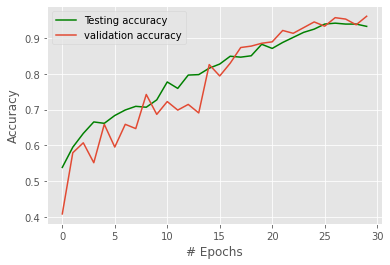

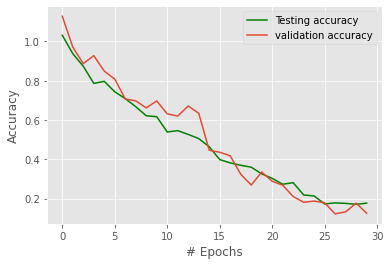

0.9320513010025024


In [7]:

plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['accuracy'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/CNN_acc.png")
plt.show()


plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['loss'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_loss'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/CNN_loss.png")
plt.show()


acc=history.history['accuracy'][-1]
print(acc)



## Mobilenet model building

In [8]:
base_model = tf.keras.applications.MobileNet(input_shape=(224,224, 3), include_top=False,
                          weights='imagenet')
model1 = Sequential()
model1.add(base_model)
model1.add(GlobalAveragePooling2D())
model1.add(Dense(64, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.2))
model1.add(Dense(3, activation='sigmoid'))
model1.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history=model.fit_generator(training_set,epochs = 30,validation_data = test_set,verbose = 1)

model.save("models/mobilenet.h5")


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenet_1.00_224 (Function (None, 7, 7, 1024)        3228864   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1024)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 64)                65600     
_________________________________________________________________
batch_normalization (BatchNo (None, 64)                256       
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_5 (Dense)              (None, 3)                 195       
Total params: 3,294,915
Trainable params: 3,272,899
Non-trainable params: 22,016
_______________________________________

c:\Program Files\Python36\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/30
65/65 [==============================] - 41s 621ms/step - loss: 0.1652 - accuracy: 0.9359 - val_loss: 0.1550 - val_accuracy: 0.9206
Epoch 2/30
65/65 [==============================] - 40s 616ms/step - loss: 0.0904 - accuracy: 0.9654 - val_loss: 0.0803 - val_accuracy: 0.9762
Epoch 3/30
65/65 [==============================] - 40s 613ms/step - loss: 0.1695 - accuracy: 0.9436 - val_loss: 0.1748 - val_accuracy: 0.9524
Epoch 4/30
65/65 [==============================] - 39s 605ms/step - loss: 0.1365 - accuracy: 0.9513 - val_loss: 0.1177 - val_accuracy: 0.9643
Epoch 5/30
65/65 [==============================] - 40s 606ms/step - loss: 0.1049 - accuracy: 0.9628 - val_loss: 0.0566 - val_accuracy: 0.9762
Epoch 6/30
65/65 [==============================] - 40s 612ms/step - loss: 0.1107 - accuracy: 0.9513 - val_loss: 0.1201 - val_accuracy: 0.9762
Epoch 7/30
65/65 [==============================] - 40s 609ms/step - loss: 0.1515 - accuracy: 0.9500 - val_loss: 0.0835 - val_accuracy: 0.9722

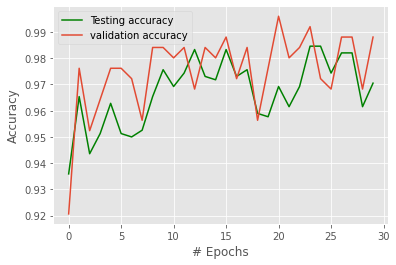

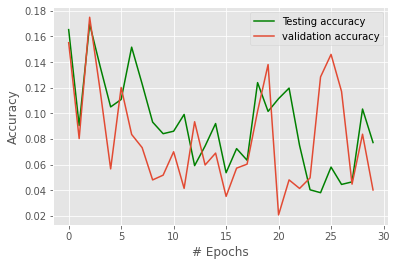

0.9705128073692322


In [9]:

plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['accuracy'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/mobilenet_acc.png")
plt.show()



plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['loss'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_loss'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/mobilenet_loss.png")
plt.show()


acc=history.history['accuracy'][-1]
print(acc)

